# Globe — data on a textured sphere

`Scene3D.globe` drapes a lon/lat field onto a WGS84 sphere (via the optional **geovista**) with Natural-Earth coastlines. The field must be in lon/lat — reproject projected rasters upstream in pyramids (`dataset.to_crs(4326)`). geovista is imported lazily inside `globe()`, so the rest of the tier works without it.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from pyramids.dataset import Dataset
from digitalearth.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'

def show(scene, title=''):
    """Screenshot a scene off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]          # exclude the bottom colour-bar strip
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} of the scene differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


## A synthetic global field

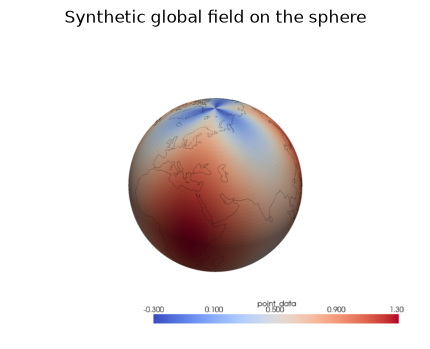

In [2]:
lon = np.linspace(-180, 180, 145)
lat = np.linspace(-90, 90, 73)
field = np.add.outer(np.cos(np.deg2rad(lat)), 0.3 * np.sin(np.deg2rad(3 * lon)))
scene = Scene3D(off_screen=True)
scene.globe(get_source(field, x=lon, y=lat), cmap='coolwarm', coastlines=True)
show(scene, 'Synthetic global field on the sphere')
scene.close()

## Real global data (WorldClim mean January temperature)

A real lon/lat raster read through pyramids and draped on the globe. The WorldClim file is large sample data
(gitignored, not committed), so this cell renders only when it's present locally and skips with a note otherwise
— the stored output below was produced from a local run.

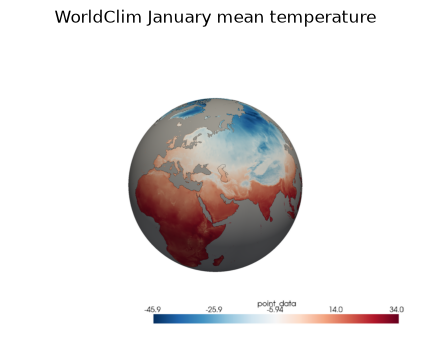

In [3]:
# WorldClim is a large, gitignored sample (not committed to the repo). Render it when it's present locally;
# in CI / a fresh clone the file is absent, so skip with a note rather than failing.
tavg_path = DATA / 'global' / 'wc2.1_10m_tavg_01.tif'
if tavg_path.exists():
    tavg = Dataset.read_file(str(tavg_path))
    scene = Scene3D(off_screen=True)
    scene.globe(tavg, cmap='RdBu_r', coastlines=True, coastline_color='black')
    show(scene, 'WorldClim January mean temperature')
    scene.close()
else:
    print(f'skipped — {tavg_path.name} is not bundled with the repo (gitignored sample data)')


## Coastline styling

`coastline_resolution` (`'110m'`/`'50m'`/`'10m'`) and `coastline_color` tune the overlay; `coastlines=False` drops it.

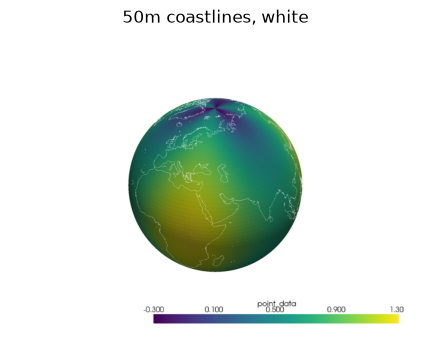

In [4]:
scene = Scene3D(off_screen=True)
scene.globe(get_source(field, x=lon, y=lat), cmap='viridis',
            coastlines=True, coastline_resolution='50m', coastline_color='white')
show(scene, '50m coastlines, white')
scene.close()